In [1]:
import os

data_dir_1 = os.path.join('..', 'data', 'case_study_1_revised')
data_dir_2 = os.path.join('..', 'data', 'case_study_2_revised')
result_dir_1 = os.path.join('..', 'data', 'case_study_1_revised')
result_dir_2 = os.path.join('..', 'data', 'case_study_2_revised')

In [2]:
import os
import numpy as np
import pd
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.tree import DecisionTreeRegressor, export_graphviz
from sklearn.model_selection import train_test_split


def predict_metric_precompiled(path, target_metric, iteration, train_sizes=[], test_size=200):
    
    results_list = []
    
    test_ds = pd.read_csv(os.path.join(path, f'sub_dataset_{test_size}_test_{iteration}.csv'), delimiter=';')
    
    ignored = [
        col for col in test_ds.columns
        if col.endswith('from_ref') or col.endswith('from_mean') or col == 'cluster' or col == 'id'
    ]
    
    y_test = test_ds[target_metric]
    X_test = test_ds.drop(columns=ignored).copy()
    
    for train_size in train_sizes:
        
        train_ds = pd.read_csv(os.path.join(path, f'sub_dataset_{train_size}_train_{iteration}.csv'), delimiter=';')
        
        y_train = train_ds[target_metric]
        X_train = train_ds.drop(columns=ignored).copy()

        regressor = DecisionTreeRegressor(random_state=42*iteration, max_depth=4)
        regressor.fit(X_train, y_train)
        y_pred = regressor.predict(X_test)
    
        mape = mean_absolute_percentage_error(y_test, y_pred)
    
        features = X_train.columns
        importances = regressor.feature_importances_
        feat_importances = {feat: imp for feat, imp in zip(features, importances) if imp > 0.0}
    
        # Store the decision tree as text
        tree_rules = export_graphviz(
                regressor,
                out_file=None,
                feature_names=X_train.columns.values,
                filled=True,
                rounded=True,
                special_characters=True,
                leaves_parallel=True,
                proportion=True
            )
    
        results_list.append({
            'metric': target_metric,
            'train_size': train_size,
            'MAPE': mape,
            'decision_tree': tree_rules,
            'feature_importances': feat_importances,
            'nb_features': len(feat_importances)
        })
    
    # Create a DataFrame from the results
    return pd.DataFrame(results_list)

In [3]:
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.tree import DecisionTreeRegressor, export_graphviz
from sklearn.model_selection import train_test_split


def predict_metric(dataset, target_metric, iteration, train_sizes=[], test_size=200):
    
    results_list = []
    train_ds, test_ds = train_test_split(dataset, test_size=test_size, random_state=42*iteration)
    ignored = [
        col for col in test_ds.columns
        if col.endswith('from_ref') or col.endswith('from_mean') or col == 'cluster' or col == 'id'
    ]
    
    y_test = test_ds[target_metric]
    X_test = test_ds.drop(columns=ignored).copy()
    
    for train_size in train_sizes:
        
        sub_train_ds, _ = train_test_split(train_ds, train_size=train_size, random_state=42*iteration)
        
        y_train = sub_train_ds[target_metric]
        X_train = sub_train_ds.drop(columns=ignored).copy()

        regressor = DecisionTreeRegressor(random_state=42*iteration, max_depth=4)
        regressor.fit(X_train, y_train)
        y_pred = regressor.predict(X_test)
    
        mape = mean_absolute_percentage_error(y_test, y_pred)
    
        features = X_train.columns
        importances = regressor.feature_importances_
        feat_importances = {feat: imp for feat, imp in zip(features, importances) if imp > 0.0}
    
        # Store the decision tree as text
        tree_rules = export_graphviz(
                regressor,
                out_file=None,
                feature_names=X_train.columns.values,
                filled=True,
                rounded=True,
                special_characters=True,
                leaves_parallel=True,
                proportion=True
            )
    
        results_list.append({
            'metric': target_metric,
            'train_size': train_size,
            'MAPE': mape,
            'decision_tree': tree_rules,
            'feature_importances': feat_importances,
            'nb_features': len(feat_importances)
        })
    
    # Create a DataFrame from the results
    return pd.DataFrame(results_list)

In [4]:
import pandas as pd

corr_func = 'spearman'

metrics = [f'{corr_func}_from_ref', f'{corr_func}_from_mean']

full_regression_path_1 = os.path.join(data_dir_1, 'regression', 'full')
dataset_1_path = os.path.join(data_dir_1, 'normalized_dataset.csv')
dataset_1 = pd.read_csv(dataset_1_path, delimiter=';')


all_results = []

for i in range(1, 11):
    for metric in metrics:
        results_df = pd.DataFrame()
        if metric.endswith('from_mean'):
            results_df = predict_metric_precompiled(full_regression_path_1, metric, i, [80, 160, 240, 320, 400, 480, 560, 640, 720], 200)
        elif metric.endswith('from_ref'):
            results_df = predict_metric(dataset_1, metric, i, [80, 160, 240, 320, 400, 480, 560, 640, 720], 200)
        results_df['iteration'] = i
        all_results.append(results_df)
        
full_results_df_1 = pd.concat(all_results, ignore_index=True)

In [5]:
metrics = [f'{corr_func}_from_ref', f'{corr_func}_from_mean']

all_results = []

valid_regression_path_1 = os.path.join(data_dir_1,'regression', 'valid')
valid_df_1_path = os.path.join(data_dir_1, 'valid_dataset.csv')
valid_df_1 = pd.read_csv(valid_df_1_path, delimiter=';')

for i in range(1, 11):
    for metric in metrics:
        results_df = pd.DataFrame()
        if metric.endswith('from_mean'):
            results_df = predict_metric_precompiled(valid_regression_path_1, metric, i, [59, 118, 178, 237, 297, 356, 415, 475, 534], 149)
        elif metric.endswith('from_ref'):
            results_df = predict_metric(valid_df_1, metric, i, [59, 118, 178, 237, 297, 356, 415, 475, 534], 149)
        results_df['iteration'] = i
        all_results.append(results_df)

valid_results_df_1 = pd.concat(all_results, ignore_index=True)

In [6]:
corr_func = 'spearman'

metrics = [f'{corr_func}_from_ref', f'{corr_func}_from_mean']

full_regression_path_2 = os.path.join(data_dir_2, 'regression', 'full')
dataset_2_path = os.path.join(data_dir_2, 'normalized_dataset.csv')
dataset_2 = pd.read_csv(dataset_2_path, delimiter=';')

all_results = []

for i in range(1, 11):
    for metric in metrics:
        results_df = pd.DataFrame()
        if metric.endswith('from_mean'):
            results_df = predict_metric_precompiled(full_regression_path_2, metric, i, [80, 160, 240, 320, 400, 480, 560, 640, 720], 200)
        elif metric.endswith('from_ref'):
            results_df = predict_metric(dataset_2, metric, i, [80, 160, 240, 320, 400, 480, 560, 640, 720], 200)
        results_df['iteration'] = i
        all_results.append(results_df)
        
full_results_df_2 = pd.concat(all_results, ignore_index=True)
print(len(full_results_df_2))

180


In [7]:
metrics = [f'{corr_func}_from_ref', f'{corr_func}_from_mean']

all_results = []

valid_regression_path_2 = os.path.join(data_dir_2, 'regression', 'valid')
valid_df_2_path = os.path.join(data_dir_2, 'valid_dataset.csv')
valid_df_2 = pd.read_csv(valid_df_2_path, delimiter=';')

for i in range(1, 11):
    for metric in metrics:
        results_df = pd.DataFrame()
        if metric.endswith('from_mean'):
            results_df = predict_metric_precompiled(valid_regression_path_2, metric, i,  [69, 138, 208, 277, 347, 416, 485, 555, 624], 174)
        elif metric.endswith('from_ref'):
            results_df = predict_metric(valid_df_2, metric, i,  [69, 138, 208, 277, 347, 416, 485, 555, 624], 174)
        results_df['iteration'] = i
        all_results.append(results_df)

valid_results_df_2 = pd.concat(all_results, ignore_index=True)

# Regression decision tree learning curves

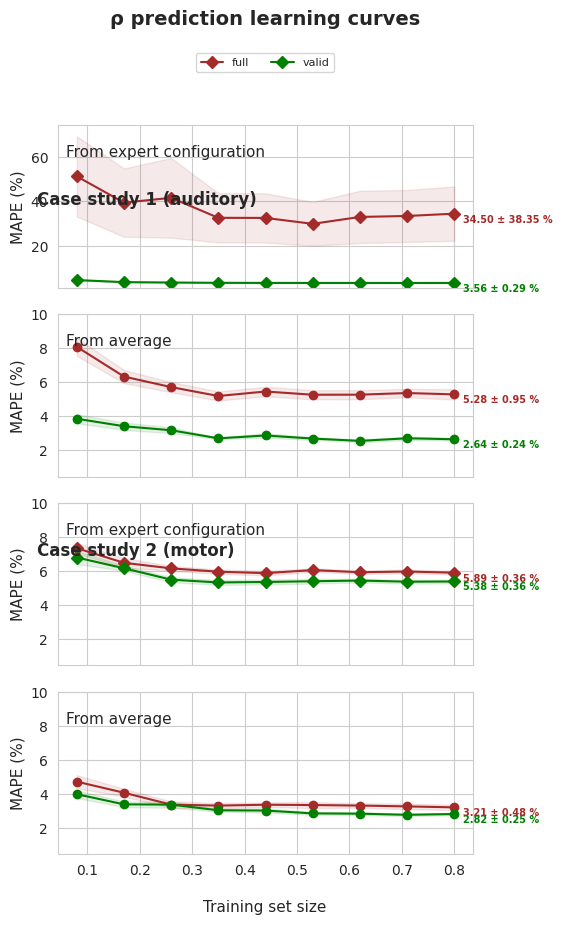

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# Function to process data
def process_data(df):
    grouped = df.groupby(["metric", "train_size"])["MAPE"].agg(
        ["mean", "std", "count"]
    ).reset_index()
    return grouped.pivot(
        index="train_size", columns="metric", values=["mean", "std", "count"]
    )


train_sizes = np.linspace(0.1, 1.0, 9) * 0.8

# Process data for both use cases
pivot_full_1 = process_data(full_results_df_1)
pivot_valid_1 = process_data(valid_results_df_1)
pivot_full_2 = process_data(full_results_df_2)
pivot_valid_2 = process_data(valid_results_df_2)

# Extract mean and standard error for each use case
mean_mape_ref_full_1 = pivot_full_1["mean"][f"{corr_func}_from_ref"]
se_mape_ref_full_1 = pivot_full_1["std"][f"{corr_func}_from_ref"] / np.sqrt(
    pivot_full_1["count"][f"{corr_func}_from_ref"]
)
mean_mape_mean_full_1 = pivot_full_1["mean"][f"{corr_func}_from_mean"]
se_mape_mean_full_1 = pivot_full_1["std"][f"{corr_func}_from_mean"] / np.sqrt(
    pivot_full_1["count"][f"{corr_func}_from_mean"]
)

mean_mape_ref_valid_1 = pivot_valid_1["mean"][f"{corr_func}_from_ref"]
se_mape_ref_valid_1 = pivot_valid_1["std"][f"{corr_func}_from_ref"] / np.sqrt(
    pivot_valid_1["count"][f"{corr_func}_from_ref"]
)
mean_mape_mean_valid_1 = pivot_valid_1["mean"][f"{corr_func}_from_mean"]
se_mape_mean_valid_1 = pivot_valid_1["std"][f"{corr_func}_from_mean"] / np.sqrt(
    pivot_valid_1["count"][f"{corr_func}_from_mean"]
)

mean_mape_ref_full_2 = pivot_full_2["mean"][f"{corr_func}_from_ref"]
se_mape_ref_full_2 = pivot_full_2["std"][f"{corr_func}_from_ref"] / np.sqrt(
    pivot_full_2["count"][f"{corr_func}_from_ref"]
)
mean_mape_mean_full_2 = pivot_full_2["mean"][f"{corr_func}_from_mean"]
se_mape_mean_full_2 = pivot_full_2["std"][f"{corr_func}_from_mean"] / np.sqrt(
    pivot_full_2["count"][f"{corr_func}_from_mean"]
)

mean_mape_ref_valid_2 = pivot_valid_2["mean"][f"{corr_func}_from_ref"]
se_mape_ref_valid_2 = pivot_valid_2["std"][f"{corr_func}_from_ref"] / np.sqrt(
    pivot_valid_2["count"][f"{corr_func}_from_ref"]
)
mean_mape_mean_valid_2 = pivot_valid_2["mean"][f"{corr_func}_from_mean"]
se_mape_mean_valid_2 = pivot_valid_2["std"][f"{corr_func}_from_mean"] / np.sqrt(
    pivot_valid_2["count"][f"{corr_func}_from_mean"]
)

# Create a 4x1 single column layout with unlinked y-axes
fig, axes = plt.subplots(4, 1, figsize=(6, 9.5), sharex=True, sharey=False)
ax1, ax2, ax3, ax4 = axes

# Define configurations for the 4 plots
plots_config = [
    (
        ax1,
        [mean_mape_ref_full_1, mean_mape_ref_valid_1],
        [se_mape_ref_full_1, se_mape_ref_valid_1],
        [
            pivot_full_1["std"][f"{corr_func}_from_ref"],
            pivot_valid_1["std"][f"{corr_func}_from_ref"],
        ],
        "Case study 1 (auditory)",
        "From expert configuration",
        "D",
    ),
    (
        ax2,
        [mean_mape_mean_full_1, mean_mape_mean_valid_1],
        [se_mape_mean_full_1, se_mape_mean_valid_1],
        [
            pivot_full_1["std"][f"{corr_func}_from_mean"],
            pivot_valid_1["std"][f"{corr_func}_from_mean"],
        ],
        "Case study 1 (auditory)",
        "From average",
        "o",
    ),
    (
        ax3,
        [mean_mape_ref_full_2, mean_mape_ref_valid_2],
        [se_mape_ref_full_2, se_mape_ref_valid_2],
        [
            pivot_full_2["std"][f"{corr_func}_from_ref"],
            pivot_valid_2["std"][f"{corr_func}_from_ref"],
        ],
        "Case study 2  (motor)",
        "From expert configuration",
        "D",
    ),
    (
        ax4,
        [mean_mape_mean_full_2, mean_mape_mean_valid_2],
        [se_mape_mean_full_2, se_mape_mean_valid_2],
        [
            pivot_full_2["std"][f"{corr_func}_from_mean"],
            pivot_valid_2["std"][f"{corr_func}_from_mean"],
        ],
        "Case study 2 (motor)",
        "From average",
        "o",
    ),
]

colors = ["brown", "green"]
datasets = ["full", "valid"]

# Draw all plots
for i, (ax, means, ses, stds, case_title, metric_title, marker) in enumerate(
    plots_config
):
    for mean, se, color, dataset in zip(means, ses, colors, datasets):
        ax.plot(
            train_sizes,
            mean * 100,
            marker=marker,
            color=color,
            linestyle="-",
            label=f"{dataset}",
        )
        ax.fill_between(
            train_sizes,
            (mean - se) * 100,
            (mean + se) * 100,
            alpha=0.1,
            color=color,
        )

    for mean, std, color in zip(means, stds, colors):
        label_text = f"{mean.iloc[-1] * 100:.2f} ± {std.iloc[-1] * 100:.2f} %"
        ax.annotate(
            label_text,
            (train_sizes[-1], mean.iloc[-1] * 100),
            textcoords="offset points",
            xytext=(6, -6),
            ha="left",
            fontsize=7,
            color=color,
            fontweight="bold",
        )

    # Independent limit for the first plot (ax1)
    if i == 0:
        all_vals = np.concatenate(
            [((m - s) * 100).values for m, s in zip(means, ses)]
            + [((m + s) * 100).values for m, s in zip(means, ses)]
        )
        ax.set_ylim(max(0, all_vals.min() - 2), all_vals.max() + 5)

    ax.grid(True)
    ax.set_ylabel("MAPE (%)", fontsize=11)
    ax.text(
        0.02,
        0.88,
        metric_title,
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment="top",
    )

# Compute a shared unified y-limit for the last 3 plots with a max of 10
later_plots_configs = plots_config[1:]
all_later_vals = []
for _, means, ses, _, _, _, _ in later_plots_configs:
    all_later_vals.extend([((m - s) * 100).values for m, s in zip(means, ses)])
    all_later_vals.extend([((m + s) * 100).values for m, s in zip(means, ses)])

shared_ymin = max(0, np.min(all_later_vals) - 2)

# Apply the shared y-limit to ax2, ax3, and ax4 capped at 10 max
for ax in [ax2, ax3, ax4]:
    ax.set_ylim(shared_ymin, 10)

# Add exterior Case Study headers using figure coordinates positioned precisely above each pair
fig.text(
    0.12,
    0.77,
    "Case study 1 (auditory)",
    fontweight="bold",
    fontsize=12,
    ha="left",
    va="center",
)
fig.text(
    0.12,
    0.40,
    "Case study 2 (motor)",
    fontsize=12,
    fontweight="bold",
    ha="left",
    va="center",
)

fig.suptitle("ρ prediction learning curves", fontsize=14, fontweight="bold", y=0.97)
fig.text(0.5, 0.02, "Training set size", ha="center", fontsize=11)

# Create a compact common legend at the top
handles, labels = ax1.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 0.93),
    fontsize=8,
)

plt.tight_layout(rect=[0.05, 0.04, 1, 0.90])
plt.savefig("regression_learning_curve.svg", format="svg", bbox_inches="tight")
plt.show()

In [9]:
def compile_and_generate_latex(iterations):
    """
    Compile mean, min, max for each feature across iterations,
    order by mean importance, and generate a LaTeX table.

    Args:
        iterations (list of dict): List of dictionaries, each representing an iteration.
    Returns:
        str: LaTeX code for the table.
    """
    # Initialize a dictionary to hold compiled data
    compiled = {}

    # Iterate over each iteration
    for iteration in iterations:
        for feature, (importance, _, _) in iteration.items():
            if feature not in compiled:
                compiled[feature] = {"values": []}
            compiled[feature]["values"].append(importance)

    # Calculate mean, min, max for each feature
    for feature in compiled:
        values = compiled[feature]["values"]
        compiled[feature]["mean"] = sum(values) / len(values)
        compiled[feature]["min"] = min(values)
        compiled[feature]["max"] = max(values)

    # Sort features by mean importance (descending)
    sorted_features = sorted(
        compiled.items(),
        key=lambda x: x[1]["mean"],
        reverse=True
    )

    # Generate LaTeX table
    latex_code = r"""
\begin{table}
  \caption{Feature importances (correlations to average statistic maps)}
  \label{tab:from_mean}
  \begin{tabular}{ccl}
\toprule
\textbf{Feature} & \textbf{Importance [min-max]} \\
\midrule
"""

    for feature, data in sorted_features:
        mean = round(data["mean"], 1)
        min_val = round(data["min"], 1)
        max_val = round(data["max"], 1)
        latex_code += f"{feature} & {mean}\% [{min_val}-{max_val}]\\\\\n"

    latex_code += r"""
  \bottomrule
\end{tabular}
\end{table}
"""
    return latex_code

<>:50: SyntaxWarning: invalid escape sequence '\%'
<>:50: SyntaxWarning: invalid escape sequence '\%'
/home/ymerel/tmp/ipykernel_29065/3458708490.py:50: SyntaxWarning: invalid escape sequence '\%'
  latex_code += f"{feature} & {mean}\% [{min_val}-{max_val}]\\\\\n"


In [10]:
# Example usage:
iterations = full_results_df_1

latex_table = compile_and_generate_latex(iterations)
print(latex_table)

/home/ymerel/tmp/ipykernel_29065/3458708490.py:50: SyntaxWarning: invalid escape sequence '\%'
  latex_code += f"{feature} & {mean}\% [{min_val}-{max_val}]\\\\\n"


AttributeError: 'str' object has no attribute 'items'